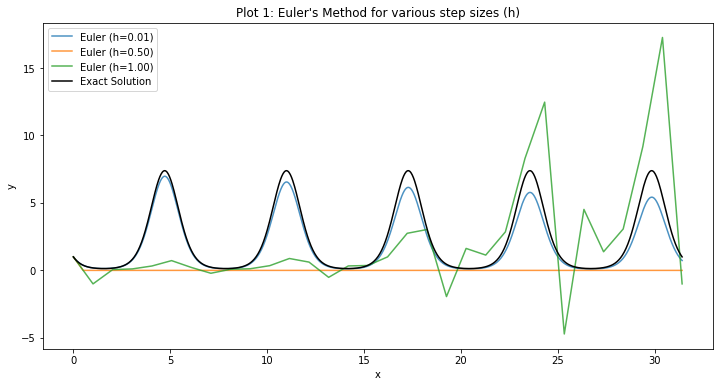

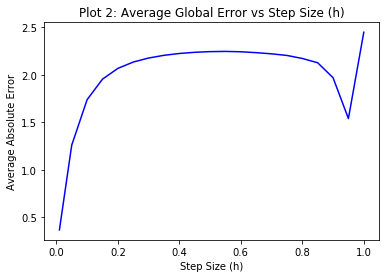

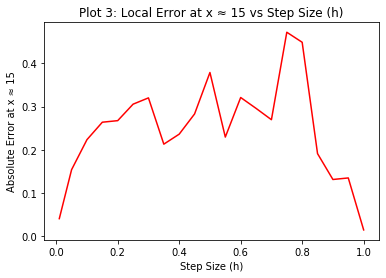

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Exact Solution and ODE
def exact_solution(x):
    return np.exp(-2 * np.sin(x))

def f(x, y):
    return -2 * y * np.cos(x)

# 2. Parameters Setup
x_start, x_end = 0, 10 * np.pi
y0 = 1

# Generate the h values: 0.01, 0.05, 0.1, 0.15 ... up to 1.0
h_values = [0.01] + list(np.arange(0.05, 1.05, 0.05))

avg_errors = []
local_errors_15 = []
h_plot = []

plt.figure(figsize=(12, 6))

# 3. Implement Euler's Method for each step size
for h in h_values:
    num_steps = int((x_end - x_start) / h)
    x_vals = np.linspace(x_start, x_end, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    
    # Initial condition
    y_vals[0] = y0 
    
    for i in range(num_steps):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])

    y_exact = exact_solution(x_vals)
    
    error_array = np.abs(y_vals - y_exact)
    avg_errors.append(np.mean(error_array))
    
    idx_15 = np.argmin(np.abs(x_vals - 15))
    local_errors_15.append(error_array[idx_15])
    h_plot.append(h)
    
    if h in [0.01, 0.15, 0.5, 1.0]:
        plt.plot(x_vals, y_vals, label=f"Euler (h={h:.2f})", alpha=0.8)

#Plots      
x_fine = np.linspace(x_start, x_end, 1000)
plt.plot(x_fine, exact_solution(x_fine), color='black' , label='Exact Solution')
plt.title("Plot 1: Euler's Method for various step sizes (h)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plt.plot(h_plot, avg_errors, color='blue')
plt.title("Plot 2: Average Global Error vs Step Size (h)")
plt.xlabel("Step Size (h)")
plt.ylabel("Average Absolute Error")
plt.show()

plt.plot(h_plot, local_errors_15, color='red')
plt.title("Plot 3: Local Error at x ≈ 15 vs Step Size (h)")
plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error at x ≈ 15")
plt.show()

From graph 1, we can see that as the step size increases, the graph becomes more sporadic with greater peaks and dips. This is because taking large steps causes instability in the estimate. In the second geraph, we see that as the step size increases, absolute error also increases except for a short dip at around 0.9. This is because the error over the interval is proportional to h due to the local error being proportional to x^2. In the third plot, the error follows a similar trend to graph 2 although with far greater spikes. This is because truncation errors cause greater harm in local error than in other methods.

## ADDENDUM

To maintain stability accross the interval, we must bound our step size by h is less than or equal to 1. This is because if we have a size greater than 1, the amplification factor will exceed 1 causeing artifially high error. Therefore, to main